This our second notebook for model training. We're taking everything from model1.ipynb and polishing it, while also adding some new features.

## Pre-processing

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

We'll load our TPM/CFU data as a dataframe, then view.

In [3]:
# Load all data
all_data_pre = pd.read_csv("C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/all_model_data.csv")

# Move condition column to index
all_data_pre.rename(columns = {"Unnamed: 0": "Condition"}, inplace = True)
all_data_pre = all_data_pre.set_index("Condition")
all_data_pre.head(n = 5)

,SP_0001,SP_0002,SP_0003,SP_0004,SP_0005,SP_0006,SP_0007,SP_0008,SP_0009,SP_0010,...,SP_2231,SP_2233,SP_2234,SP_2235,SP_2236,SP_2237,SP_2238,SP_2239,SP_2240,CFU
Condition,,,,,,,,,,,,,,,,,,,,,
12AMX1hr-a,100.731718,62.523979,29.350576,136.628654,23.311941,18.360644,23.639356,54.915731,16.204642,49.999429,...,58.423669,5.190549,31.812428,12.352542,18.789319,0.000000,19.378051,1556.989150,2065.824961,1.380000e+09
12AMX1hr-b,110.761813,85.441234,30.011332,140.199108,12.290825,19.560271,10.495536,73.411867,11.391497,55.575063,...,49.943212,7.297677,28.384337,13.025337,23.951352,11.120270,13.622331,1560.789227,2192.495376,1.500000e+09
12AMX1hr-c,86.013352,62.605378,31.936738,128.435857,15.992967,18.401074,28.330836,63.601162,11.038218,47.381206,...,57.586997,5.050970,23.932111,11.333492,18.576600,24.629493,19.799804,1510.799073,1961.293782,1.440000e+09
12AMX2hr-a,58.112596,60.819299,42.382520,189.375150,24.848367,31.648666,49.926659,100.851174,27.094345,73.751491,...,50.583010,4.700939,18.412179,7.376283,13.194701,6.612310,21.985932,1074.685060,1070.619314,3.240000e+09
12AMX2hr-b,53.327570,56.106699,32.410598,193.525955,47.194380,29.561315,66.208488,138.513586,9.373100,74.497309,...,51.480457,5.504255,25.478260,10.717449,14.490841,0.000000,18.414236,1000.733037,996.438310,3.260000e+09


We'll check if any data has 0 CFU, which will mess our analysis up when we log-transform the CFUS.

In [4]:
print(np.where(all_data_pre["CFU"] == 0))
print(all_data_pre.index[all_data_pre["CFU"] == 0].tolist())

(array([404]),)
['34CEF4hr-c']


Let's log-transform our CFU values, then remove the row with $-\infty$ CFU, which corresponds to the row we identified above. We can also check the range of CFU values to make sure it's reasonable for our modeling purposes.

In [5]:
# Log-transform CFUs
all_data_log = all_data_pre.copy()
all_data_log["CFU"] = np.log(all_data_log["CFU"])

# Filter out column with 0 CFU since log is -inf
all_data_log.replace([-np.inf], np.nan, inplace=True)
all_data_log.dropna(inplace = True)

# Checking the range of the log rmalized CFUs, this looks fine
print(f"Log CFU min : {all_data_log["CFU"].min()}")
print(f"Log CFU max : {all_data_log["CFU"].max()}")
print(f"Log CFU mean: {all_data_log["CFU"].mean()} \n")

# Check dimensions of data
print(f"# training examples : {all_data_log.shape[0]}")
print(f"# genes/features    : {all_data_log.shape[1]}")

Log CFU min : 12.89921982609012
Log CFU max : 24.323314077353732
Log CFU mean: 19.35072249856656 

# training examples : 470
# genes/features    : 2192


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Let's also load our annotations so that we can use them later for interpretability.

In [6]:
# Read annotations
annotations = pd.read_csv("C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/Annotation_TIGR4.tsv", sep = "\t")

# Set gene ID as index
annotations.set_index("TIGR4.old", inplace = True, drop = True)

# Dimensions
print(annotations.shape)
print(annotations.columns)
annotations.head(n = 5)

(1800, 30)
Index(['Cluster', 'Subcluster', 'Product', 'Strain', 'Genome', 'locus',
       'Start', 'End', 'Strand', 'Total.Insertions', 'Total.Sites', 'zbar',
       'Binomial.Call', 'HMM.Call', 'D39.old', 'TAIWAN.19F.new',
       'TAIWAN.19F.old', 'D39.new', 'GENE.DESCRIPTION', 'GENE.CATEGORY',
       'Location.Tag', 'Tag1', 'Tag2', 'Tag3', 'Category1', 'Category2',
       'Category3', 'No..of.Categories', 'Gene.Name',
       'GO.terms..biological.process.'],
      dtype='str')


,Cluster,Subcluster,Product,Strain,Genome,locus,Start,End,Strand,Total.Insertions,...,Location.Tag,Tag1,Tag2,Tag3,Category1,Category2,Category3,No..of.Categories,Gene.Name,GO.terms..biological.process.
TIGR4.old,,,,,,,,,,,,,,,,,,,,,
n.p.,1,1_5,DUF3278 domain-containing protein,TIGR4-AC316,CP035239,EQH41_02925,552132,553134,-1,57,...,NaN,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP_0582,1,1_2,endonuclease/exonuclease/phosphatase family pr...,TIGR4-AC316,CP035239,EQH41_02925,552132,553134,-1,57,...,Membrane,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
SP_0828,2,2_0,ribose-5-phosphate isomerase RpiA,TIGR4-AC316,CP035239,EQH41_04105,777989,778673,1,5,...,Intracellular,METABOLISM,NaN,NaN,Carbohydrate metabolism,NaN,NaN,1.0,rpiA,"pentose-phosphate shunt, non-oxidative branch ..."
SP_1113,3,3_0,HU family DNA-binding protein,TIGR4-AC316,CP035239,EQH41_05540,1042358,1042634,1,0,...,Intracellular,GENETIC INFORMATION PROCESSING,NaN,NaN,Replication,NaN,NaN,1.0,NaN,chromosome condensation
SP_1925,4,4_0,hypothetical protein,TIGR4-AC316,CP035239,EQH41_09740,1826524,1827133,-1,16,...,NaN,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


Note that only 1800 out of 2192 genes are annotated. This is because we have some "in-between" fragments that were picked up in the RNA-seq experiment. Okay, we can subset our annotations to the stuff we actually care about.

In [7]:
# Gene data
annotations = annotations[["Product", "Tag1", "Tag2", "Tag3", "GENE.CATEGORY", "GENE.DESCRIPTION", "Location.Tag", "Category1", "Category2", "Category3", "Gene.Name", "GO.terms..biological.process."]]
annotations.head(n = 5)

,Product,Tag1,Tag2,Tag3,GENE.CATEGORY,GENE.DESCRIPTION,Location.Tag,Category1,Category2,Category3,Gene.Name,GO.terms..biological.process.
TIGR4.old,,,,,,,,,,,,
n.p.,DUF3278 domain-containing protein,HYPOTHETICAL/UNKNOWN,NaN,NaN,UNKNOWN,hypothetical protein,NaN,NaN,NaN,NaN,NaN,NaN
SP_0582,endonuclease/exonuclease/phosphatase family pr...,HYPOTHETICAL/UNKNOWN,NaN,NaN,UNKNOWN,hypothetical protein,Membrane,NaN,NaN,NaN,NaN,NaN
SP_0828,ribose-5-phosphate isomerase RpiA,METABOLISM,NaN,NaN,CARBOHYDRATE METABOLISM,ribose 5-phosphate isomerase,Intracellular,Carbohydrate metabolism,NaN,NaN,rpiA,"pentose-phosphate shunt, non-oxidative branch ..."
SP_1113,HU family DNA-binding protein,GENETIC INFORMATION PROCESSING,NaN,NaN,DNA TURNOVER,DNA-binding protein HU,Intracellular,Replication,NaN,NaN,NaN,chromosome condensation
SP_1925,hypothetical protein,HYPOTHETICAL/UNKNOWN,NaN,NaN,UNKNOWN,hypothetical protein,NaN,NaN,NaN,NaN,NaN,NaN


## Functions for training/evaluating models

### Train/test split

We need to group our conditions by triplicate, because we want each set of triplicates to end up together in either the train or test set. We can write a function to produce indices for us based on our input data. We'll assume that each triplicates has the same label, other than the last character, which can be "a", "b", or "c".

In [8]:
# Parameters : cond_list (list of condition labels, ex: "12CIP1hr-a", "12CIP1hr-b", etc)
# Output     : groups (list of labels according to condition, ex: 0, 0, 0, 1, 1, 1, etc.)
def groups_by_cond(cond_list):

    # Initialize list to store groups
    groups = [0]

    # Loop through conditions, beginning at second position
    for i in range(1, len(cond_list)):
        
        # Previous condition
        prev = cond_list[i-1]   
        curr = cond_list[i]

        # Matching label (apart from last letter)
        if prev[:-1] == curr[:-1]:
            groups.append(groups[i-1])
        
        # New label
        else:
            groups.append(groups[i-1] + 1)
    
    return groups

Next, let's define a function to do the following, given an X (predictors) and y (target):
1. Generate a list of groups for condition labels
2. Generate a splitter object
3. Obtain train and test indices for the train/test split
4. Generate train/test set

In [9]:
from sklearn.model_selection import GroupShuffleSplit 

# Parameters : X (predictors), y (target), train_size (0-1), group_func (group-making function)
# Output     : X_train, y_train, X_test, y_test

# Note: X must be a dataframe with index defined as condition name
#       y can be a dataframe or a series with index defined the same as X

def group_ttsplit(X, y, train_size, group_func):

    # Make splitter
    gss = GroupShuffleSplit(n_splits = 1, train_size = train_size, random_state = 111)

    # Define groups
    groups = group_func(X.index)

    # Obtain indices for train and test split
    train_idx, test_idx = next(gss.split(X, groups = groups))

    # Define train, test sets
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test   = X.iloc[test_idx], y.iloc[test_idx]

    return X_train, y_train, X_test, y_test

Now, we'll write a function that generates a PrettyTable for us including all of the metrics that we want (R^2 train, R^2 test, MSE, MAE)

In [10]:
from sklearn import ensemble
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn import preprocessing

import prettytable
from prettytable import PrettyTable

# Parameters : title, model_list (list of trained models), name_list (list of model names), data (X_train, y_train, X_test, y_test)
# Output     : Table with each model including R^2 train, R^2 test, MSE, MAE

def eval_table(title, model_list, name_list, data):

    # Initialize table for eval metrics
    table = PrettyTable(["Model", "RMSE", "MAE", "R^2 (Train)", "R^2 (Test)"])

    # Load data
    X_train_, y_train_ = data[0], data[1]
    X_test_, y_test_   = data[2], data[3]

    # Add model eval metrics to table
    for i in range(len(model_list)):

        # Compute predictions
        preds = model_list[i].predict(X_test_)

        # Add eval metrics
        table.add_row([name_list[i],
                       round(root_mean_squared_error(y_test_, preds), 4),
                       round(mean_absolute_error(y_test_, preds), 4),
                       round(model_list[i].score(X_train_, y_train_), 4),
                       round(model_list[i].score(X_test_, y_test_), 4)])
    
    # Title
    table.title = title

    return table

This function will take a regression model, then output the features sorted in decreasing order by their coefficients, along with annotations.

In [11]:
# Parameters : model, training_data (as df with labeled index)
# Output     : DF of features sorted by 
def feature_sort_reg(model, training_data):

    # Extract feature names from training_data df
    gene_names = training_data.columns

    # Construct df with named coefficients
    coefs = pd.DataFrame(np.ndarray.flatten(model.coef_), columns = ["coef"], index = gene_names)

    # Reorder coeffs from greatest to least absolute value
    coefs = coefs.iloc[np.argsort(-np.abs(coefs["coef"]))]

    return coefs

We can define the same for a random forest model.

In [12]:
# Parameters : model, training_data (as df with labeled index)
# Output     : DF of features sorted by 
def feature_sort_tree(model, training_data):

    # Extract feature names from training_data df
    gene_names = training_data.columns

    # Construct df with named coefficients
    coefs = pd.DataFrame(np.ndarray.flatten(model.feature_importances_), columns = ["coef"], index = gene_names)

    # Reorder coeffs from greatest to least absolute value
    coefs = coefs.iloc[np.argsort(-np.abs(coefs["coef"]))]

    return coefs

Next, we'll define a function to plot the top $n$ features based on the magnitude of their coefficients.

In [13]:
# Parameteres : coefs (df of coefs ordered by magnitude, with index), n (# coefs to see), 
#               annotations (for features), title
# Output      : plot

def plot_coefs(coefs, n, annots, title):

    # Merge coefficients with annotations
    annotated = pd.merge(coefs, annots, how = "left", left_index = True, right_index = True)

    # Subplots
    fig, ax = plt.subplots()

    # Barplot of coefficients
    annotated.iloc[:n].plot(kind = "barh", ax = ax).invert_yaxis()

    # Plot
    ax.set_title(title)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Gene")
    ax.axvline(x = 0, color = ".5")

    # Secondary axis for gene IDs
    secax = ax.secondary_yaxis("left")
    secax.set_yticks(range(len(annotated.iloc[:30].index)))
    secax.set_yticklabels(annotated.iloc[:30]["Product"])
    secax.spines['left'].set_position(('outward', 130))
    secax.set_ylabel("Gene product")

## Train on all standard-scaled features

Train/test split on all the original data.

In [14]:
# Load data
X_all = all_data_log.iloc[:, all_data_log.columns != "CFU"]
y_all = all_data_log.iloc[:, all_data_log.columns == "CFU"]

# Split data
all_split = group_ttsplit(X_all, y_all, 0.7, groups_by_cond)
X_all_train, y_all_train = all_split[0], all_split[1]
X_all_test, y_all_test   = all_split[2], all_split[3]

In [15]:
X_all_test.shape

(144, 2191)

This time, we'll try applying a standardscaler to all of our features. This will subtract all features by the the correpsonding mean and scale by the std.

In [16]:
from sklearn.preprocessing import StandardScaler

# Scalers for train and test data (separate so we don't have to resplit)
scaler1 = StandardScaler()

# Set output to preserve df
scaler1.set_output(transform = "pandas")

# Fit scalers
scaler1.fit(X_all_train)

# Transform data
X_scaled_train = scaler1.transform(X_all_train)
X_scaled_test  = scaler1.transform(X_all_test)

X_scaled_train

,SP_0001,SP_0002,SP_0003,SP_0004,SP_0005,SP_0006,SP_0007,SP_0008,SP_0009,SP_0010,...,SP_2230,SP_2231,SP_2233,SP_2234,SP_2235,SP_2236,SP_2237,SP_2238,SP_2239,SP_2240
Condition,,,,,,,,,,,,,,,,,,,,,
12AMX2hr-a,-1.012134,-0.832045,-0.530206,-0.400631,-0.616867,-0.213616,0.040940,-0.273010,0.051021,-0.314887,...,-0.811277,-0.748943,-0.442792,-1.051621,-0.983474,-0.862038,-0.379369,-0.628798,-1.235519,-1.310944
12AMX2hr-b,-1.081937,-0.916452,-0.697443,-0.375981,0.398222,-0.319903,0.578200,0.300181,-0.842459,-0.300437,...,-0.839947,-0.731335,-0.329097,-0.780473,-0.762308,-0.804225,-1.052122,-0.810395,-1.377807,-1.409970
12AMX2hr-c,-1.046824,-1.080235,-0.677382,-0.559396,-0.205425,-0.229665,0.683454,-0.410901,-0.008319,-0.460099,...,-0.912802,-0.790522,-0.887822,-0.547270,-0.806184,-0.807178,-0.569475,-0.016089,-1.382960,-1.468107
12CEF12CIP1hr-a,-0.188859,-0.608585,-0.392525,-0.566141,-0.201093,-0.419377,0.668907,-0.488966,1.068242,-0.501024,...,0.169564,-0.199829,-1.108125,-0.799429,0.146779,-0.342296,-0.269648,-0.514915,1.411536,-0.001283
12CEF12CIP1hr-b,-0.267593,-0.083908,0.237828,-0.639242,0.040637,-0.365260,-0.249760,-0.053322,-0.377527,-0.360999,...,0.357944,-0.138376,-0.265152,-0.529777,-0.144774,-0.635068,-1.052122,0.385261,1.459158,0.043491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34VNC2hr-b,-0.290795,-0.015210,-0.531306,-0.700483,-0.797539,-0.207806,-0.304299,-1.036839,-0.479072,-0.794110,...,-1.110600,-0.654723,-0.920208,-0.220853,-0.425949,-0.432984,-0.228734,-0.378504,-0.914727,-0.996912
34VNC2hr-c,-0.565770,-0.367794,-0.532674,-0.509231,-0.292892,-0.502928,-0.884457,-0.525908,-0.644464,-0.698339,...,-1.208320,-0.789492,-0.203694,-0.453434,-0.711607,-0.546526,0.080137,-0.954490,-0.943150,-0.953375
NDC4hr-a,-1.460004,-1.116219,-0.851839,-1.092458,-0.966377,-0.477589,-0.398095,-0.396382,-0.039748,-0.502000,...,-1.101263,-1.133400,-0.698592,-0.564616,-0.651257,-0.732950,-0.334349,0.371875,-0.303010,-0.336411


Train and fit 5 models.

In [17]:
# Models
scaled_lm    = linear_model.LinearRegression()
scaled_lasso = linear_model.LassoCV(cv = 5)
scaled_ridge = linear_model.RidgeCV(cv = 5)
scaled_en    = linear_model.ElasticNetCV(cv = 5)
scaled_rf    = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)

# Fit
scaled_lm.fit(X_scaled_train, y_all_train)
scaled_lasso.fit(X_scaled_train, y_all_train)
scaled_ridge.fit(X_scaled_train, y_all_train)
scaled_en.fit(X_scaled_train, y_all_train)
scaled_rf.fit(X_scaled_train, y_all_train)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.133e-01, tolerance: 1.021e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklea

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Look at the regularization hyperparameters:

Evaluate.

In [18]:
print(eval_table(title = "Models with all standard-scaled features",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train, y_all_train, X_scaled_test, y_all_test]))

+------------------------------------------------------------+
|          Models with all standard-scaled features          |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.8283 | 0.5959 |     1.0     |   0.7802   |
|     LASSO     | 0.8776 | 0.585  |    0.9728   |   0.7532   |
|     Ridge     | 0.821  | 0.5888 |    0.9999   |   0.784    |
|   ElasticNet  | 0.8736 | 0.5859 |    0.9808   |   0.7554   |
| Random Forest | 0.9977 | 0.6776 |    0.9851   |   0.681    |
+---------------+--------+--------+-------------+------------+


We're also interested in finding the performance metrics of the model only on certain data types. Let's try subsetting our data based on the condition name, so that we can see the R^2 on different drugs! 

In [19]:
# Indices of each datatype in the train/test sets

# CIP
cip_index_train = [i for i in range(X_scaled_train.shape[0]) if "CIP" in X_scaled_train.iloc[i].name and
                   "CEF" not in X_scaled_train.iloc[i].name and 
                   "VNC" not in X_scaled_train.iloc[i].name]
cip_index_test  = [i for i in range(X_scaled_test.shape[0]) if "CIP" in X_scaled_test.iloc[i].name and
                   "CEF" not in X_scaled_test.iloc[i].name and 
                   "VNC" not in X_scaled_test.iloc[i].name]

# CEF
cef_index_train = [i for i in range(X_scaled_train.shape[0]) if "CEF" in X_scaled_train.iloc[i].name
                   and "CIP" not in X_scaled_train.iloc[i].name]
cef_index_test  = [i for i in range(X_scaled_test.shape[0]) if "CEF" in X_scaled_test.iloc[i].name
                   and "CIP" not in X_scaled_test.iloc[i].name]

# AMX
amx_index_train = [i for i in range(X_scaled_train.shape[0]) if "AMX" in X_scaled_train.iloc[i].name]
amx_index_test  = [i for i in range(X_scaled_test.shape[0]) if "AMX" in X_scaled_test.iloc[i].name]

# VNC
vnc_index_train = [i for i in range(X_scaled_train.shape[0]) if "VNC" in X_scaled_train.iloc[i].name
                   and "CIP" not in X_scaled_train.iloc[i].name]
vnc_index_test  = [i for i in range(X_scaled_test.shape[0]) if "VNC" in X_scaled_test.iloc[i].name
                   and "CIP" not in X_scaled_test.iloc[i].name]

Let's do the same for single vs. multiple drug data

In [20]:
# Single drug (check that there are 3 capital letters in the name)
single_index_train = [i for i in range(X_scaled_train.shape[0]) if sum(1 for char in X_scaled_train.iloc[i].name if char.isupper()) == 3]
single_index_test  = [i for i in range(X_scaled_test.shape[0]) if sum(1 for char in X_scaled_test.iloc[i].name if char.isupper()) == 3]

# Combination drug (check that there are 6 capital letters in the name)
combo_index_train = [i for i in range(X_scaled_train.shape[0]) if sum(1 for char in X_scaled_train.iloc[i].name if char.isupper()) == 6]
combo_index_test  = [i for i in range(X_scaled_test.shape[0]) if sum(1 for char in X_scaled_test.iloc[i].name if char.isupper()) == 6]


Now we can make eval tables for each datatype!

In [21]:
tbl1 = eval_table(title = "Model performance on CIP data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[cip_index_train], y_all_train.iloc[cip_index_train], X_scaled_test.iloc[cip_index_test], y_all_test.iloc[cip_index_test]])
tbl2 = eval_table(title = "Model performance on CEF data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[cef_index_train], y_all_train.iloc[cef_index_train], X_scaled_test.iloc[cef_index_test], y_all_test.iloc[cef_index_test]])
tbl3 = eval_table(title = "Model performance on AMX data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[amx_index_train], y_all_train.iloc[amx_index_train], X_scaled_test.iloc[amx_index_test], y_all_test.iloc[amx_index_test]])
tbl4 = eval_table(title = "Model performance on VNC data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[vnc_index_train], y_all_train.iloc[vnc_index_train], X_scaled_test.iloc[vnc_index_test], y_all_test.iloc[vnc_index_test]])
tbl5 = eval_table(title = "Model performance on single-drug data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[single_index_train], y_all_train.iloc[single_index_train], X_scaled_test.iloc[single_index_test], y_all_test.iloc[single_index_test]])
tbl6 = eval_table(title = "Model performance on combination data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[combo_index_train], y_all_train.iloc[combo_index_train], X_scaled_test.iloc[combo_index_test], y_all_test.iloc[combo_index_test]])

Let's plot the R^2 (train) of each model for each data type. The R^2(test) are all essentially the same.

In [22]:
# Store r^2
r2s = [row[4] for row in tbl1.rows] + [row[4] for row in tbl2.rows] + [row[4] for row in tbl3.rows] + [row[4] for row in tbl4.rows] + [row[4] for row in tbl5.rows] + [row[4] for row in tbl6.rows]

datatypes = ["CIP"]*5 + ["CEF"]*5 + ["AMX"]*5 + ["VNC"]*5 + ["Single-drug"]*5 + ["Multi-drug"]*5

# Construct dataframe of R^2 (train) for each model
evals = {
    "Model": ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"]*6,
    "Datatype": datatypes,
    "R^2 (test)": r2s
}

# DF
evals = pd.DataFrame(evals)

Text(0.5, 1.0, 'Models trained using standard-scaled features')

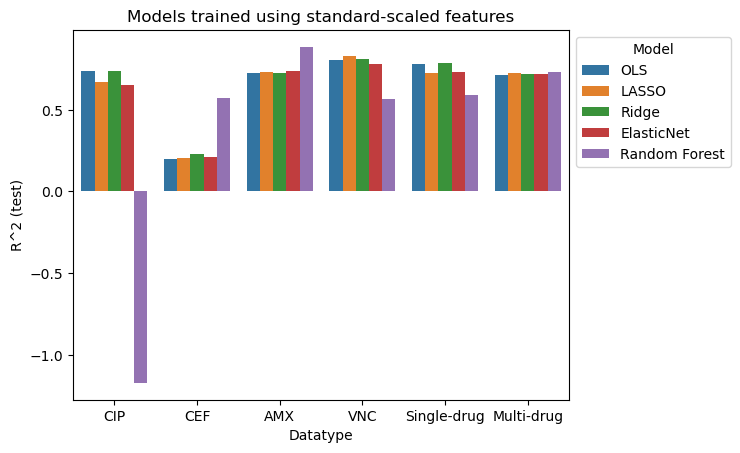

In [23]:
ax = sns.barplot(data = evals, x = "Datatype", y = "R^2 (test)", hue = "Model")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title("Models trained using standard-scaled features")

Let's visualize as scatter plots. First create a dataframe consisting of the test data CFUs, then bind all the predicted values.

In [24]:
np.unique(list(len(x) for x in X_scaled_test.index))

array([ 8,  9, 10, 15])

In [25]:
t = np.array(list(X_scaled_train.index))
[seq for seq in t if "VNC" in seq and "CIP" not in seq]

[np.str_('12VNC1hr-a'),
 np.str_('12VNC1hr-b'),
 np.str_('12VNC1hr-c'),
 np.str_('12VNC2hr-a'),
 np.str_('12VNC2hr-b'),
 np.str_('12VNC2hr-c'),
 np.str_('13VNC1hr-a'),
 np.str_('13VNC1hr-b'),
 np.str_('13VNC1hr-c'),
 np.str_('13VNC4hr-a'),
 np.str_('13VNC4hr-b'),
 np.str_('13VNC4hr-c'),
 np.str_('14VNC1hr-a'),
 np.str_('14VNC1hr-b'),
 np.str_('14VNC1hr-c'),
 np.str_('14VNC2hr-a'),
 np.str_('14VNC2hr-b'),
 np.str_('14VNC2hr-c'),
 np.str_('14VNC4hr-a'),
 np.str_('14VNC4hr-b'),
 np.str_('14VNC4hr-c'),
 np.str_('1VNC2hr-a'),
 np.str_('1VNC2hr-b'),
 np.str_('1VNC2hr-c'),
 np.str_('1VNC4hr-a'),
 np.str_('1VNC4hr-b'),
 np.str_('1VNC4hr-c'),
 np.str_('34VNC1hr-a'),
 np.str_('34VNC1hr-b'),
 np.str_('34VNC1hr-c'),
 np.str_('34VNC2hr-a'),
 np.str_('34VNC2hr-b'),
 np.str_('34VNC2hr-c')]

In [26]:
# Get true CFUs
eval_df = pd.DataFrame(y_all_test)

# Get predicted CFUs
eval_df["OLS preds"] = scaled_lm.predict(X_scaled_test)
eval_df["LASSO preds"] = scaled_lasso.predict(X_scaled_test)
eval_df["Ridge preds"] = scaled_ridge.predict(X_scaled_test)
eval_df["EN preds"] = scaled_en.predict(X_scaled_test)
eval_df["RF preds"] = scaled_rf.predict(X_scaled_test)
eval_df["Time"] = eval_df.index

# Convert ln CFUs to log10 CFUs
cols = ["CFU", "OLS preds", "LASSO preds", "Ridge preds", "EN preds", "RF preds"]
eval_df[cols] = eval_df[cols].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df["Time"] = eval_df["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df["Drug"] = eval_df.index

# Make a string reader to deal with row names and generate new columns based off of this
def drug_reader(x):

    # Single drug
    if len(x) < 11:
        
        # If NDC
        if x[:3] == "NDC":
            return "NDC"
        
        # If another drug
        else:
            
            # Construct of array of 1s and 0s depending on if character
            binary = np.array([int(char.isalpha()) for char in x])

            # Find first 1, then grap drug name
            first_char = np.where(binary == 1)[0][0]
            return x[first_char:first_char+3]
    
    # Multiple drug
    else:

        # Extract drug
        drug_name =  x[2:5] + "+" + x[7:10]
        return drug_name

eval_df["Drug"] = eval_df["Drug"].apply(drug_reader)

In [27]:
eval_df

,CFU,OLS preds,LASSO preds,Ridge preds,EN preds,RF preds,Time,Drug
Condition,,,,,,,,
12AMX1hr-a,9.139879,9.123340,9.196432,9.117061,9.218066,9.113673,1hr,AMX
12AMX1hr-b,9.176091,9.020847,9.058993,9.017118,9.050643,9.148773,1hr,AMX
12AMX1hr-c,9.158362,8.960150,8.925325,8.963142,8.892521,8.758849,1hr,AMX
12AMX4hr-a,10.176091,9.855902,9.761845,9.857239,9.796198,10.161307,4hr,AMX
12AMX4hr-b,10.209515,9.664492,9.812517,9.676200,9.808786,10.093739,4hr,AMX
...,...,...,...,...,...,...,...,...
NDC1hr-b,9.000000,8.859819,8.868148,8.862160,8.882544,8.537826,1hr,NDC
NDC1hr-c,8.903090,8.845433,8.951784,8.844740,8.972373,8.568624,1hr,NDC
NDC2hr-a,9.357935,9.448608,9.516671,9.451890,9.481574,8.970668,2hr,NDC


([<matplotlib.axis.YTick at 0x27c980c6990>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

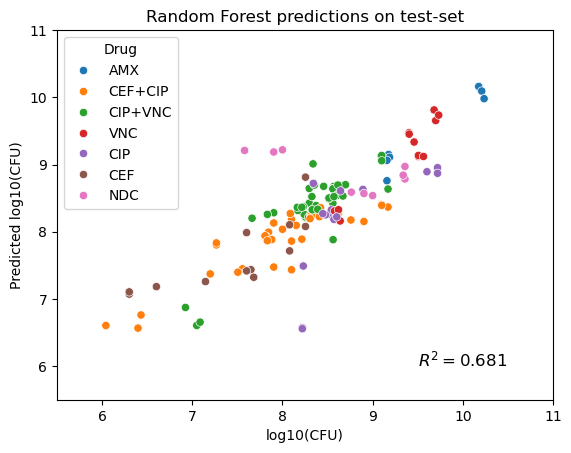

In [28]:
sns.scatterplot(eval_df, x = "CFU", y = "RF preds", hue = "Drug")
plt.title("Random Forest predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.681:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

([<matplotlib.axis.YTick at 0x27c984d4550>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

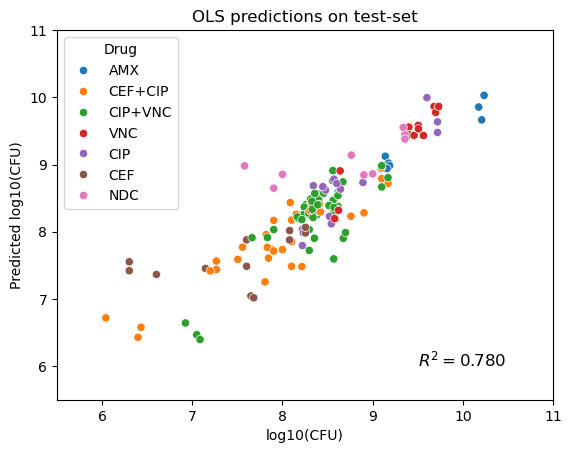

In [29]:
sns.scatterplot(eval_df, x = "CFU", y = "OLS preds", hue = "Drug")
plt.title("OLS predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.78:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

([<matplotlib.axis.YTick at 0x27c9857afd0>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

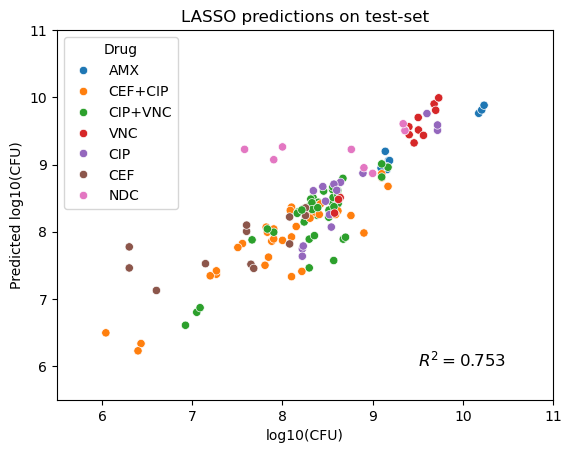

In [30]:
sns.scatterplot(eval_df, x = "CFU", y = "LASSO preds", hue = "Drug")
plt.title("LASSO predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.753:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

([<matplotlib.axis.YTick at 0x27c987b5810>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

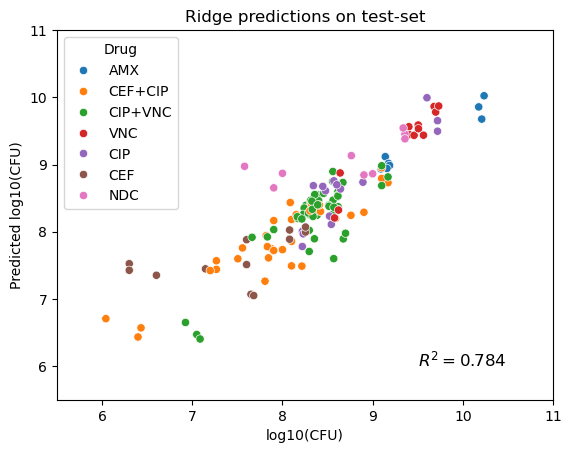

In [31]:
sns.scatterplot(eval_df, x = "CFU", y = "Ridge preds", hue = "Drug")
plt.title("Ridge predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.784:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

([<matplotlib.axis.YTick at 0x27c9896ac10>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

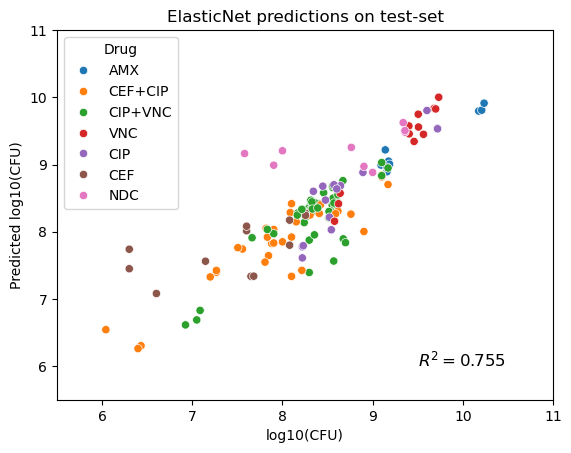

In [32]:
sns.scatterplot(eval_df, x = "CFU", y = "EN preds", hue = "Drug")
plt.title("ElasticNet predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.755:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

Stable performance across classes

Coefficient extraction:

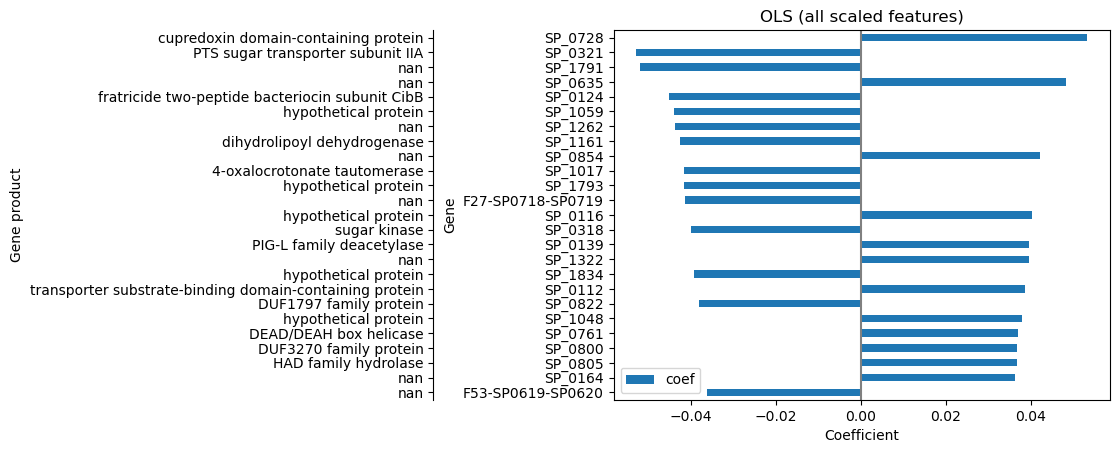

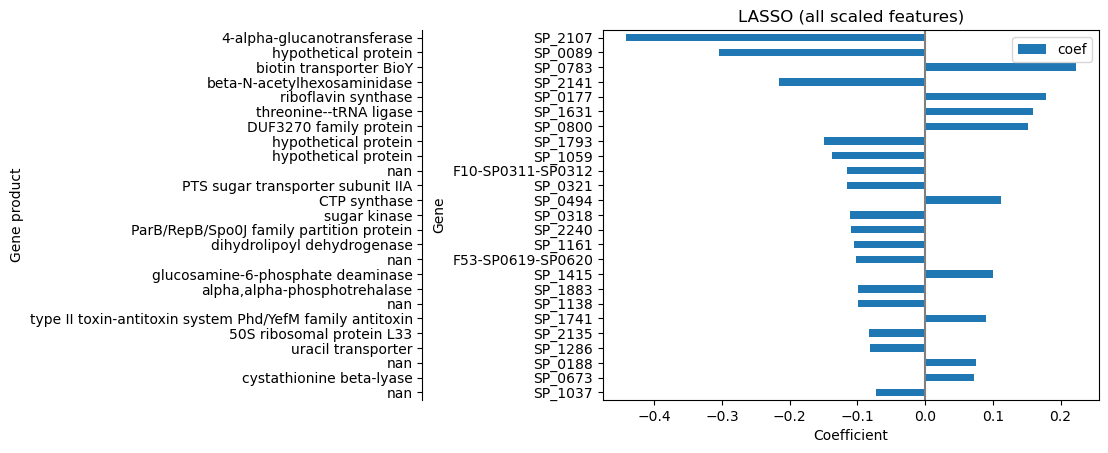

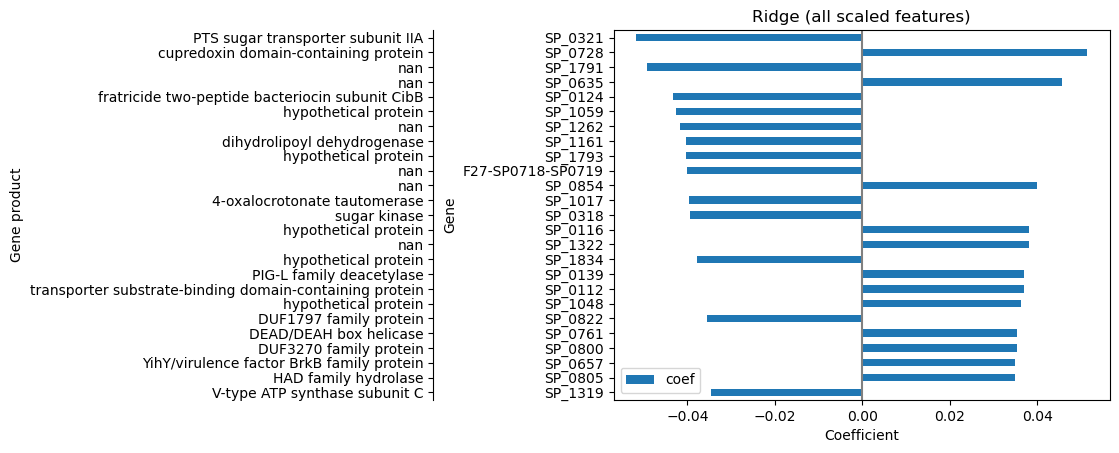

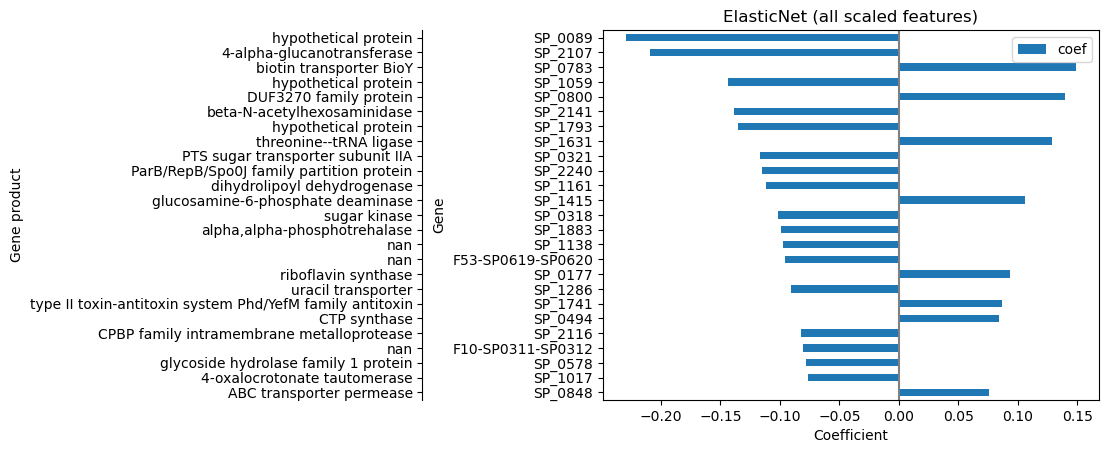

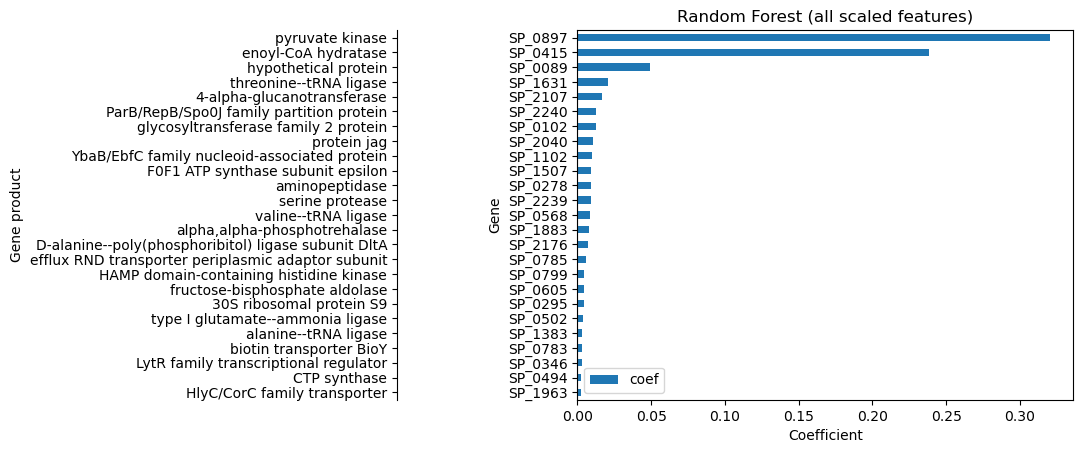

In [33]:
plot_coefs(feature_sort_reg(scaled_lm, X_scaled_train), 25, annotations, "OLS (all scaled features)")
plot_coefs(feature_sort_reg(scaled_lasso, X_scaled_train), 25, annotations, "LASSO (all scaled features)")
plot_coefs(feature_sort_reg(scaled_ridge, X_scaled_train), 25, annotations, "Ridge (all scaled features)")
plot_coefs(feature_sort_reg(scaled_en, X_scaled_train), 25, annotations, "ElasticNet (all scaled features)")
plot_coefs(feature_sort_tree(scaled_rf, X_scaled_train), 25, annotations, "Random Forest (all scaled features)")

## Train models for hold-out concentration and timepoint

### 0.25x MIC held out

In [ ]:
# Select indicies corresponding to if 1/4 MIC data
idx14_y = [i for i in range(X_all.shape[0]) if "14" in X_all.index[i]]
idx14_n = [i for i in range(X_all.shape[0]) if "14" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_14, y_train_14 = X_all.iloc[idx14_n], y_all.iloc[idx14_n]
X_test_14, y_test_14   = X_all.iloc[idx14_y], y_all.iloc[idx14_y]

# Fit scaler and transform data
scaler14 = StandardScaler()
scaler14.set_output(transform = "pandas")
scaler14.fit(X_train_14)
X_train_14 = scaler14.transform(X_train_14)
X_test_14  = scaler14.transform(X_test_14)

# Train EN model
en14 = linear_model.ElasticNetCV(cv = 5)

en14.fit(X_train_14, y_train_14)

print(eval_table(title = "0.25x MIC held out",
           model_list = [en14],
           name_list = ["ElasticNet"],
           data = [X_train_14, y_train_14, X_test_14, y_test_14]))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+---------------------------------------------------------+
|                    0.25x MIC held out                   |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 0.7311 | 0.4565 |    0.947    |   0.759    |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x27ca54a3b10>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

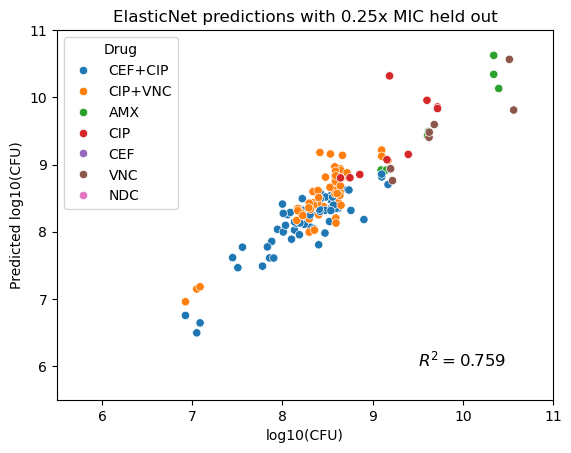

In [106]:
# Scatterplot of predictions
eval_df14 = pd.DataFrame(y_test_14)

# Get predicted CFUs
eval_df14["Preds"] = en14.predict(X_test_14)

# Log 10 conversion
eval_df14[["CFU", "Preds"]] = eval_df14[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df14["Time"] = eval_df14.index
eval_df14["Time"] = eval_df14["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df14["Drug"] = eval_df14.index

# Drug names
eval_df14["Drug"] = eval_df14["Drug"].apply(drug_reader)

# Sort alphabetically by index
eval_df14 = eval_df14.sort_index()

# Preset ordered drugs
ordered_drugs = ["CEF+CIP","CIP+VNC", "AMX", "CIP", "CEF", "VNC", "NDC"]

sns.scatterplot(eval_df14, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 0.25x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.759:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

### 0.33x MIC held out

In [82]:
# Select indicies corresponding to if 1/4 MIC data
idx13_y = [i for i in range(X_all.shape[0]) if "13" in X_all.index[i]]
idx13_n = [i for i in range(X_all.shape[0]) if "13" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_13, y_train_13 = X_all.iloc[idx13_n], y_all.iloc[idx13_n]
X_test_13, y_test_13   = X_all.iloc[idx13_y], y_all.iloc[idx13_y]

# 
scaler13 = StandardScaler()
scaler13.set_output(transform = "pandas")

# Fit scaler and transform data
scaler13.fit(X_train_13)
X_train_13 = scaler13.transform(X_train_13)
X_test_13  = scaler13.transform(X_test_13)

# Train EN model
en13 = linear_model.ElasticNetCV(cv = 5)

en13.fit(X_train_13, y_train_13)

print(eval_table(title = "0.33x MIC held out",
           model_list = [en13],
           name_list = ["ElasticNet"],
           data = [X_train_13, y_train_13, X_test_13, y_test_13]))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+---------------------------------------------------------+
|                    0.33x MIC held out                   |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 0.5777 | 0.4399 |    0.9767   |   0.8609   |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x27ca0277250>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

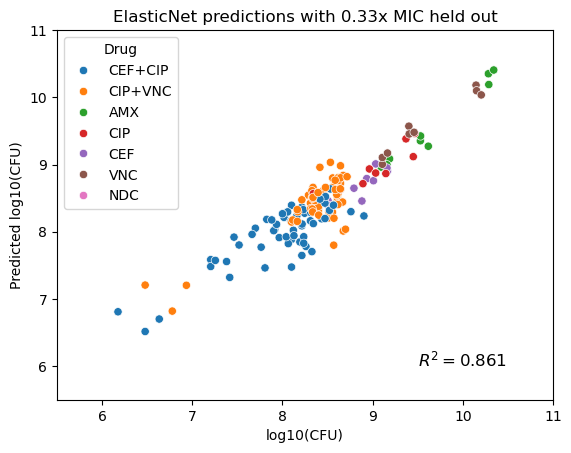

In [107]:
# Scatterplot of predictions
eval_df13 = pd.DataFrame(y_test_13)

# Get predicted CFUs
eval_df13["Preds"] = en13.predict(X_test_13)

# Log 10 conversion
eval_df13[["CFU", "Preds"]] = eval_df13[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df13["Time"] = eval_df13.index
eval_df13["Time"] = eval_df13["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df13["Drug"] = eval_df13.index

# Drug names
eval_df13["Drug"] = eval_df13["Drug"].apply(drug_reader)

sns.scatterplot(eval_df13, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 0.33x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.8609:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

### 0.5x MIC held out

In [85]:
# Select indicies corresponding to if 1/4 MIC data
idx12_y = [i for i in range(X_all.shape[0]) if "12" in X_all.index[i]]
idx12_n = [i for i in range(X_all.shape[0]) if "12" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_12, y_train_12 = X_all.iloc[idx12_n], y_all.iloc[idx12_n]
X_test_12, y_test_12   = X_all.iloc[idx12_y], y_all.iloc[idx12_y]

# 
scaler12 = StandardScaler()
scaler12.set_output(transform = "pandas")

# Fit scaler and transform data
scaler12.fit(X_train_12)
X_train_12 = scaler12.transform(X_train_12)
X_test_12  = scaler12.transform(X_test_12)

# Train EN model
en12 = linear_model.ElasticNetCV(cv = 5)

en12.fit(X_train_12, y_train_12)

print(eval_table(title = "0.50x MIC held out",
           model_list = [en12],
           name_list = ["ElasticNet"],
           data = [X_train_12, y_train_12, X_test_12, y_test_12]))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+---------------------------------------------------------+
|                    0.50x MIC held out                   |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 0.7331 | 0.5346 |    0.9819   |   0.7912   |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x27ca7226210>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

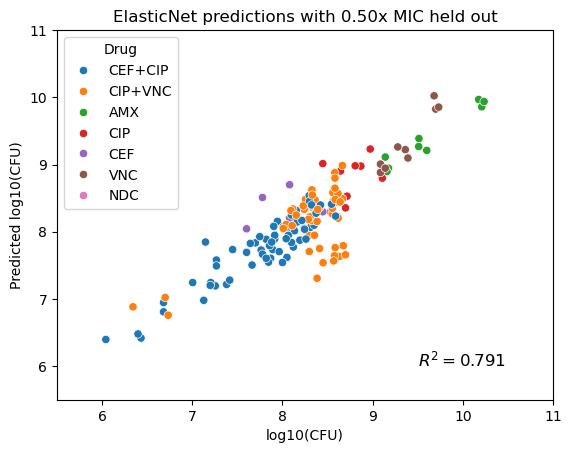

In [108]:
# Scatterplot of predictions
eval_df12 = pd.DataFrame(y_test_12)

# Get predicted CFUs
eval_df12["Preds"] = en12.predict(X_test_12)

# Log 10 conversion
eval_df12[["CFU", "Preds"]] = eval_df12[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df12["Time"] = eval_df12.index
eval_df12["Time"] = eval_df12["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df12["Drug"] = eval_df12.index

# Drug names
eval_df12["Drug"] = eval_df12["Drug"].apply(drug_reader)

sns.scatterplot(eval_df12, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 0.50x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.7912:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))


### 0.75x MIC held out

In [114]:
# Select indicies corresponding to if 1/4 MIC data
idx34_y = [i for i in range(X_all.shape[0]) if "34" in X_all.index[i]]
idx34_n = [i for i in range(X_all.shape[0]) if "34" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_34, y_train_34 = X_all.iloc[idx34_n], y_all.iloc[idx34_n]
X_test_34, y_test_34   = X_all.iloc[idx34_y], y_all.iloc[idx34_y]

# Scaler
scaler34 = StandardScaler()
scaler34.set_output(transform = "pandas")

# Fit scaler and transform data
scaler34.fit(X_train_34)
X_train_34 = scaler34.transform(X_train_34)
X_test_34  = scaler34.transform(X_test_34)

# Train EN model
en34 = linear_model.ElasticNetCV(cv = 5)

en34.fit(X_train_34, y_train_34)

print(eval_table(title = "0.75x MIC held out",
           model_list = [en34],
           name_list = ["ElasticNet"],
           data = [X_train_34, y_train_34, X_test_34, y_test_34]))


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+---------------------------------------------------------+
|                    0.75x MIC held out                   |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 1.2256 | 0.8716 |    0.9377   |   0.6059   |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x27c98883610>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

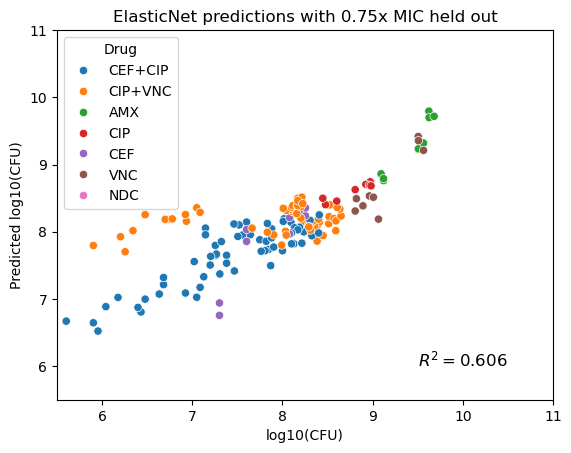

In [112]:
# Scatterplot of predictions
eval_df34 = pd.DataFrame(y_test_34)

# Get predicted CFUs
eval_df34["Preds"] = en34.predict(X_test_34)

# Log 10 conversion
eval_df34[["CFU", "Preds"]] = eval_df34[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df34["Time"] = eval_df34.index
eval_df34["Time"] = eval_df34["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df34["Drug"] = eval_df34.index

# Drug names
eval_df34["Drug"] = eval_df34["Drug"].apply(drug_reader)

sns.scatterplot(eval_df34, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 0.75x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.6059:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))


### 1x MIC Held out

In [121]:
# Select indicies corresponding to if 1/4 MIC data
idx1_y = [i for i in range(X_all.shape[0]) if X_all.index[i].startswith("1") and X_all.index[i][1].isalpha()]
idx1_n = [i for i in range(X_all.shape[0]) if not (X_all.index[i].startswith("1") and X_all.index[i][1].isalpha())]

# Subset data to 1/4 MIC or not
X_train_1, y_train_1 = X_all.iloc[idx1_n], y_all.iloc[idx1_n]
X_test_1, y_test_1   = X_all.iloc[idx1_y], y_all.iloc[idx1_y]

# Scaler
scaler1 = StandardScaler()
scaler1.set_output(transform = "pandas")

# Fit scaler and transform data
scaler1.fit(X_train_1)
X_train_1 = scaler1.transform(X_train_1)
X_test_1  = scaler1.transform(X_test_1)

# Train EN model
en1 = linear_model.ElasticNetCV(cv = 5)

en1.fit(X_train_1, y_train_1)

print(eval_table(title = "0.1x MIC held out",
           model_list = [en1],
           name_list = ["ElasticNet"],
           data = [X_train_1, y_train_1, X_test_1, y_test_1]))


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.387e-01, tolerance: 1.351e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.441e-01, tolerance: 1.351e-01
  model = cd_fast.enet_coordin

+-------------------------------------------------------+
|                   0.1x MIC held out                   |
+------------+------+--------+-------------+------------+
|   Model    | RMSE |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+------+--------+-------------+------------+
| ElasticNet | 1.67 | 1.3622 |    0.9571   |   -0.268   |
+------------+------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x27ca8c26850>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

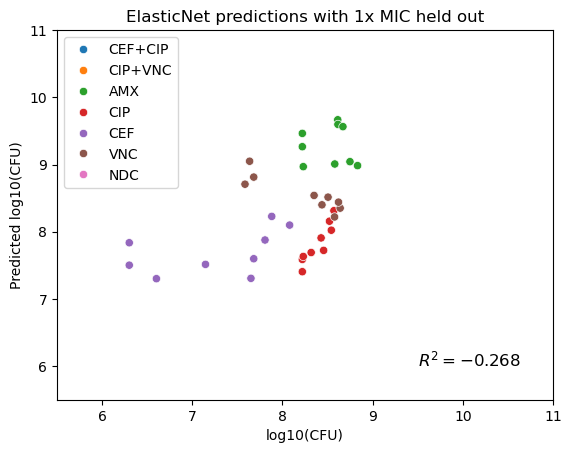

In [128]:
# Scatterplot of predictions
eval_df1 = pd.DataFrame(y_test_1)

# Get predicted CFUs
eval_df1["Preds"] = en1.predict(X_test_1)

# Log 10 conversion
eval_df1[["CFU", "Preds"]] = eval_df1[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df1["Time"] = eval_df1.index
eval_df1["Time"] = eval_df1["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df1["Drug"] = eval_df1.index

# Drug names
eval_df1["Drug"] = eval_df1["Drug"].apply(drug_reader)

sns.scatterplot(eval_df1, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 1x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {-0.268:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.legend(loc = "upper left")
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))
